Mini-project: predict if a tumor is malignant or not

We simulate patiens with two features:
- tumor size
- cell irregularity

Label:
- 0: begign
- 1: malignant

Generate fake data:

In [74]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

m = 200 # number of patiens

# we will create clear linearly separable-ish data
# benign tumors
size_b = np.random.normal(2, 0.5, m//2)
irr_b  = np.random.normal(2, 0.5, m//2)

# malignant tumors
size_m = np.random.normal(4, 0.7, m//2)
irr_m  = np.random.normal(4, 0.7, m//2)

X = np.vstack([
    np.column_stack([size_b, irr_b]),
    np.column_stack([size_m, irr_m])
])

y = np.array([0]*(m//2) + [1]*(m//2))

Text(0, 0.5, 'Cell irregularity')

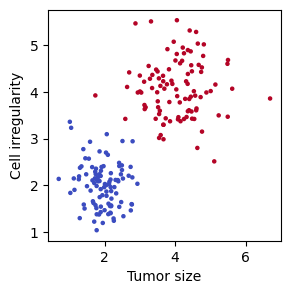

In [75]:
f, ax = plt.subplots(1,1, figsize=(3,3))
ax.scatter(X[:,0], X[:,1], c=y, marker='o', s=5, cmap='coolwarm')
ax.set_xlabel('Tumor size')
ax.set_ylabel('Cell irregularity')

Define the sigmoid (logistic) function:

$g(z) = \frac{1}{1 - e^{-z}}$

In [76]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Logistic regression model:

$f_{\vec{W},b}(\vec{X}) = g(\vec{W}\cdot\vec{X} + b)$

In [77]:
def predict_proba(X, W, b): # = f_{w,b} (x) ; returns probabilities
    z = X @ W + b
    return sigmoid(z)

Cost:

$J = - \frac{1}{m} \sum y \log (f) + (1-y) \log (1-f)$

In [78]:
def loss(X, y, W, b):
    p = predict_proba(X, W, b)
    eps = 1e-8 # for numerical stability
    return - np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

Derive gradients:

$\Delta w = \frac{1}{m} \sum_{i=1}^m (f_{\vec{W},b}(\vec{X}^i) - y^i)x_j^i = \frac{1}{m} X^T (f - y)$

$\Delta b = \frac{1}{m} \sum_{i=1}^m (f_{\vec{W},b}(\vec{X}^i) - y^i) = \frac{1}{m}\sum(f - y)$

In [79]:
def gradients(X, y, W, b):
    p = predict_proba(X, W, b)
    dW = X.T @ (p - y) / len(y)
    db = np.mean(p - y)
    return dW, db

Train: gradient descent loop

In [80]:
W = np.zeros(2)
b = 0.
lr = 0.5
n_steps = 1000

loss_history = []

for step in range(n_steps):
    dW, db = gradients(X, y, W, b)
    W -= lr * dW
    b -= lr * db
    loss_history.append(loss(X, y, W, b))

Plot the loss:

Text(0, 0.5, 'Loss')

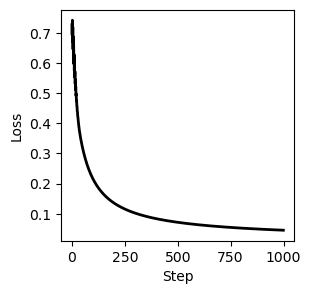

In [81]:
f, ax = plt.subplots(1,1, figsize=(3,3))
ax.plot(loss_history, lw=2, color='black')
ax.set_xlabel("Step")
ax.set_ylabel('Loss')

Decision boundary defined when $p=0.5$ which means $w_1 x_1 + w_2 x_2 + b = 0$

Then

$x_2 = - \frac{w_1 x_1 + b}{w_2}$

Text(0, 0.5, 'Cell irregularity')

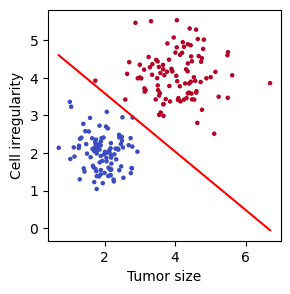

In [82]:
x1_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x2_vals = -(W[0]*x1_vals + b) / W[1]

f, ax = plt.subplots(1,1, figsize=(3,3))
ax.scatter(X[:,0], X[:,1], c=y, marker='o', s=5, cmap='coolwarm')
plt.plot(x1_vals, x2_vals, color='red')
ax.set_xlabel('Tumor size')
ax.set_ylabel('Cell irregularity')

Visualize probabilities:

Text(0, 0.5, 'Cell irregularity')

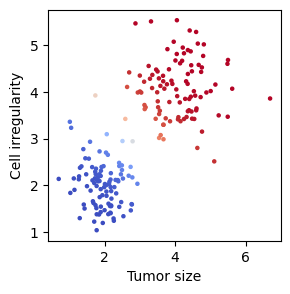

In [83]:
p = predict_proba(X, W, b)

f, ax = plt.subplots(1,1, figsize=(3,3))
ax.scatter(X[:,0], X[:,1], c=p, marker='o', s=5, cmap='coolwarm')
ax.set_xlabel('Tumor size')
ax.set_ylabel('Cell irregularity')